# Medical Insurance Charges Prediction Using Linear Regression

## 1. Introduction

This analysis investigates the factors associated with medical insurance
charges using a medical insurance dataset. Linear Regression is used to
develop a predictive model for estimating insurance charges based on
individual characteristics such as age, sex, BMI, number of children,
smoking status and region.

The analysis includes data exploration, data cleaning, exploratory data
analysis (EDA), feature preparation, model development and model
evaluation.

In [34]:
#Load Liabraries
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import  seaborn as sns
from sklearn import datasets

#Regression model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [35]:
# Load  and Explore the dataset
df = pd.read_csv("insurance.csv")

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


2. Loading the Dataset

The medical insurance dataset is loaded into a pandas DataFrame. The
dataset contains information about individuals, including age, sex,
BMI, number of children, smoking status, region and medical insurance
charges.


The first four records are displayed to examine the structure and
contents of the dataset. This provides an initial view of the variables
and the types of information available for analysis.

In [37]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


Dataset Structure

The `info()` function is used to examine the number of observations,
variables, data types and missing values in the dataset.

1,338 observations and 7 columns, with no missing values

In [39]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Descriptive Statistics

Descriptive statistics are used to understand the distribution of the
numerical variables. Measures such as the mean, standard deviation,
minimum, median and maximum values provide an overview of the dataset.

In [40]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [41]:
# Check Missing Values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Missing values can affect the reliability of a machine learning model.
Therefore, the dataset is checked for missing observations before
building the regression model.

The result shows zero missing values in all seven variables.

In [42]:
#check Duplicated Records
df.duplicated().sum()

np.int64(1)

In [43]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [44]:

# Remove duplicated rows
df = df.drop_duplicates()

# Check again
print("Duplicated rows after removal:", df.duplicated().sum())

Duplicated rows after removal: 0


In [45]:
df.duplicated().sum()

np.int64(0)


Duplicate records were checked to ensure that the same observation was
not included more than once in the dataset. The initial check identified
one duplicate record. The duplicate record was removed to avoid giving
the same observation additional influence during model training.
N.B There are no duplicate records remaining.

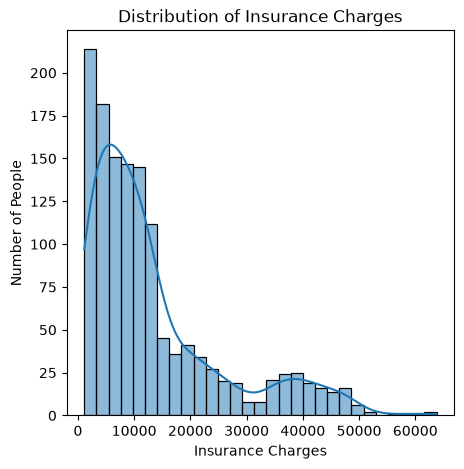

In [89]:

#Exploring Data analysis (EDA)

plt.figure(figsize=(5, 5))

sns.histplot(df['charges'], kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Number of People")

plt.show()


Exploratory Data Analysis (EDA) is performed to identify patterns,
relationships and distributions within the dataset. Visualisations are
used to examine how demographic and lifestyle variables are associated
with medical insurance charges.

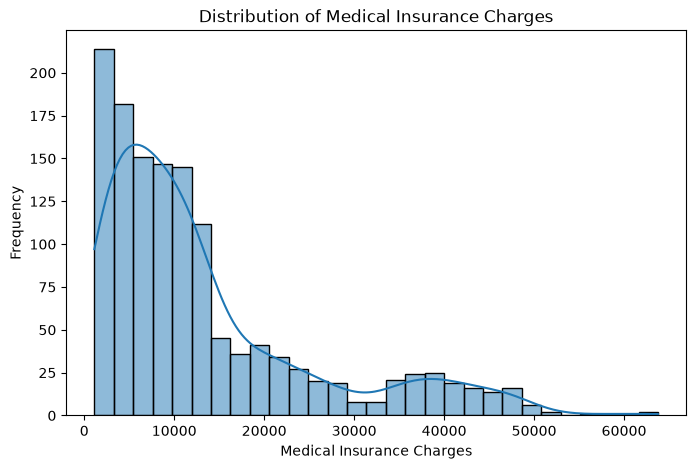

In [47]:
#Distribution of charges
plt.figure(figsize=(8, 5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Medical Insurance Charges")
plt.ylabel("Frequency")

plt.show()

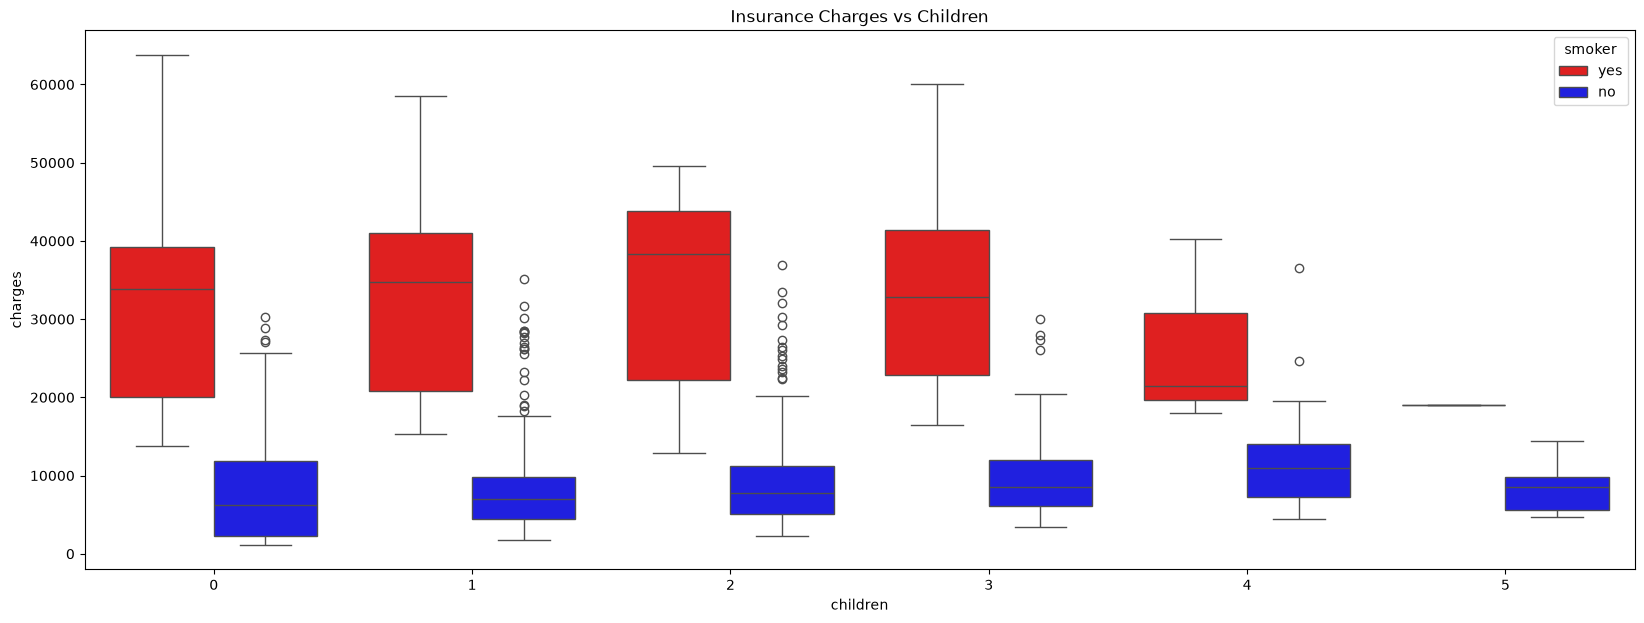

In [48]:
plt.figure(figsize=(20,7))

sns.boxplot(
    x='children',
    y='charges',
    hue='smoker',
    data=df,
    palette={'yes': 'red', 'no': 'blue'}
)

plt.title("Insurance Charges vs Children")
plt.show()


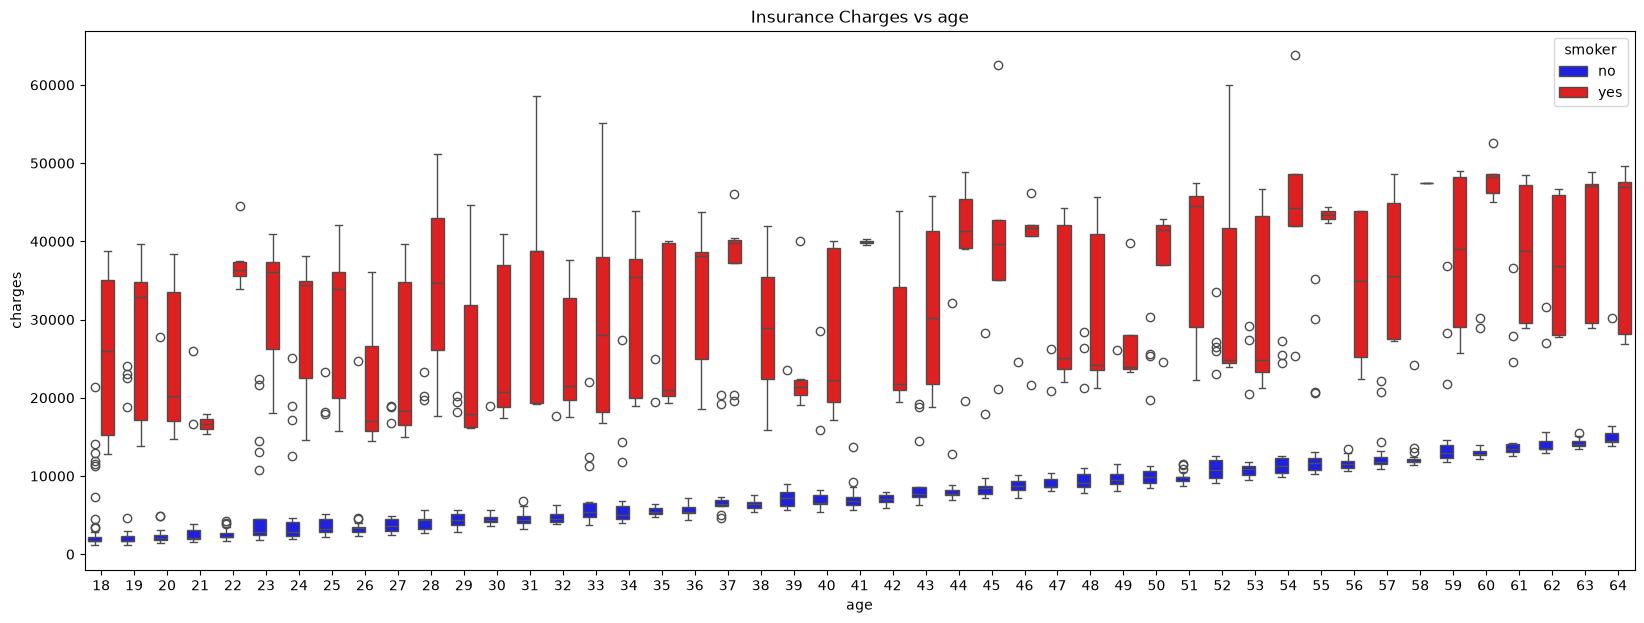

In [49]:
plt.figure(figsize=(20,7))

sns.boxplot(
    x='age',
    y='charges',
    hue='smoker',
    data=df,
    palette={'yes': 'red', 'no': 'blue'}
)

plt.title("Insurance Charges vs age")
plt.show()


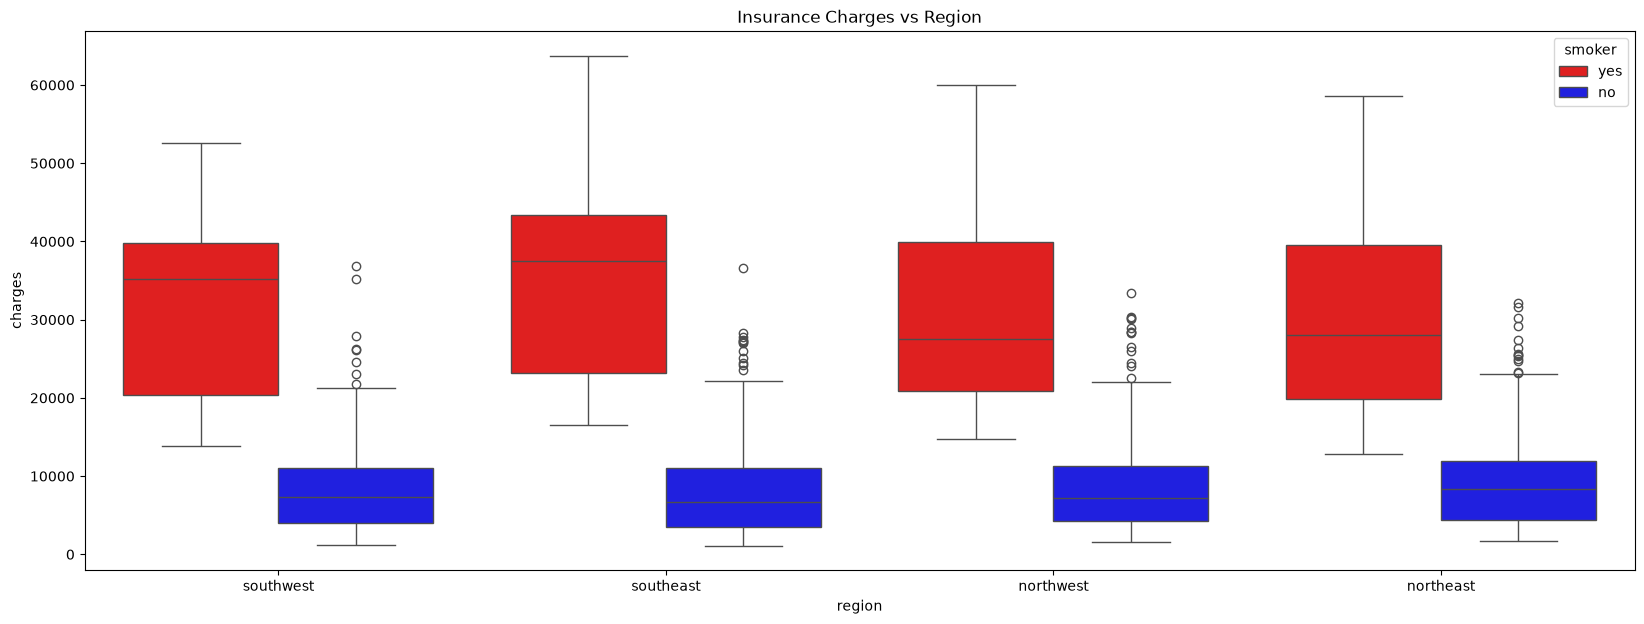

In [50]:
plt.figure(figsize=(20,7))

sns.boxplot(
    x='region',
    y='charges',
    hue='smoker',
    data=df,
    palette={'yes': 'red', 'no': 'blue'}
)

plt.title("Insurance Charges vs Region")
plt.show()


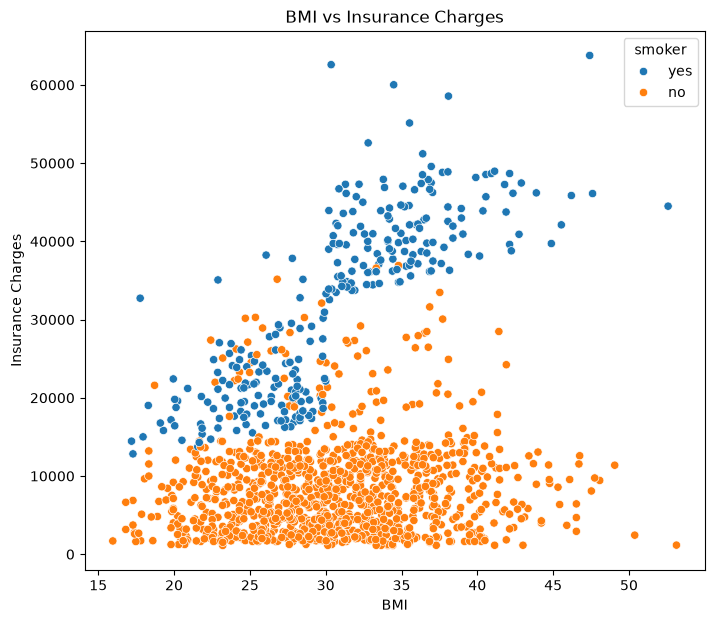

In [51]:
plt.figure(figsize=(8, 7))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

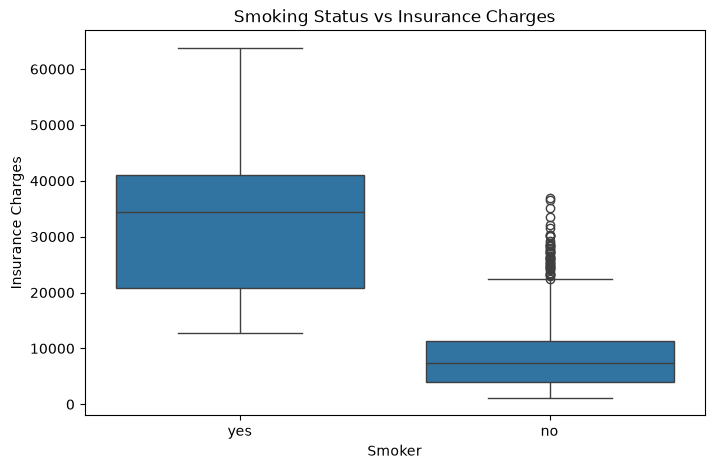

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

 Smoking Status and Medical Charges

Smoking status is examined because lifestyle characteristics may be
associated with differences in medical insurance charges.

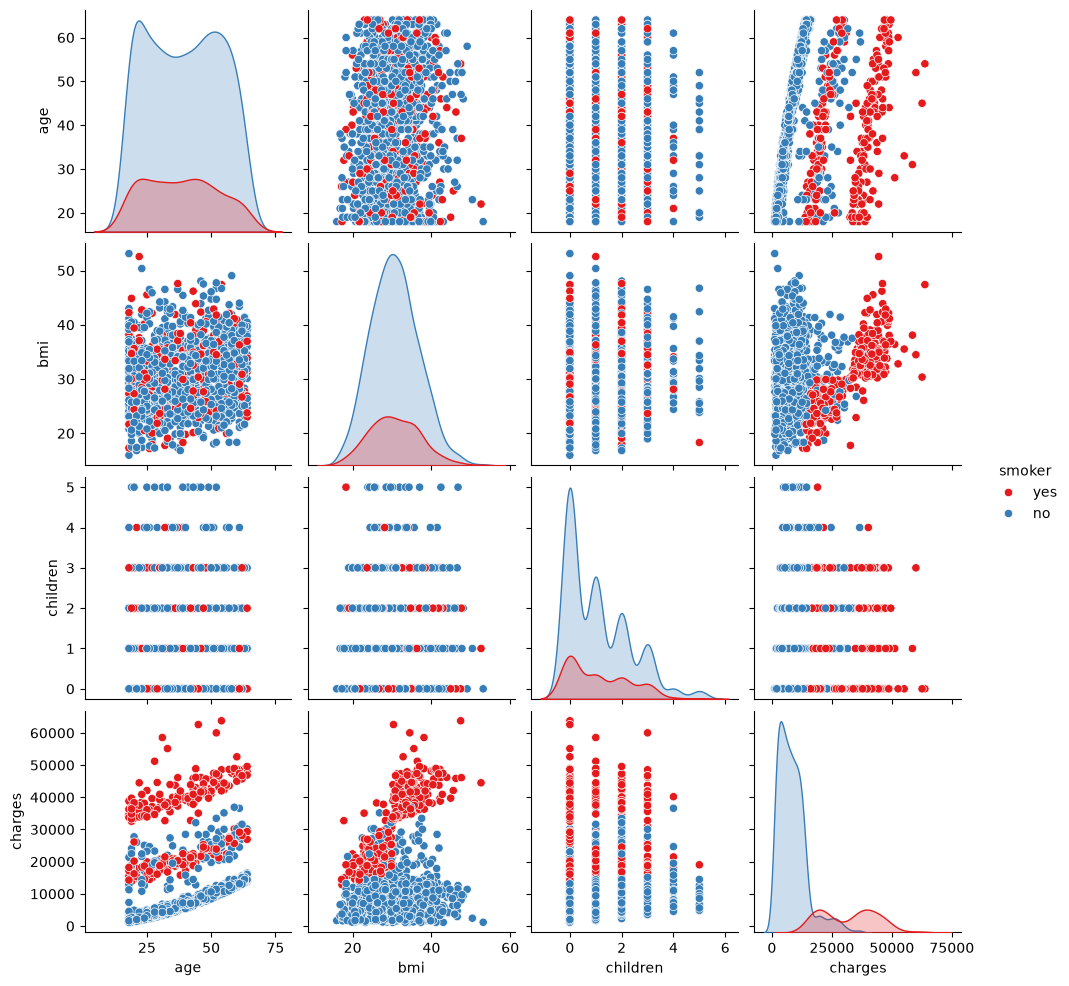

In [53]:
sns.pairplot(
    df, 
    vars=['age', 'bmi', 'children', 'charges'], 
    hue='smoker', 
    palette='Set1', 
    diag_kind='kde'
)
plt.show()


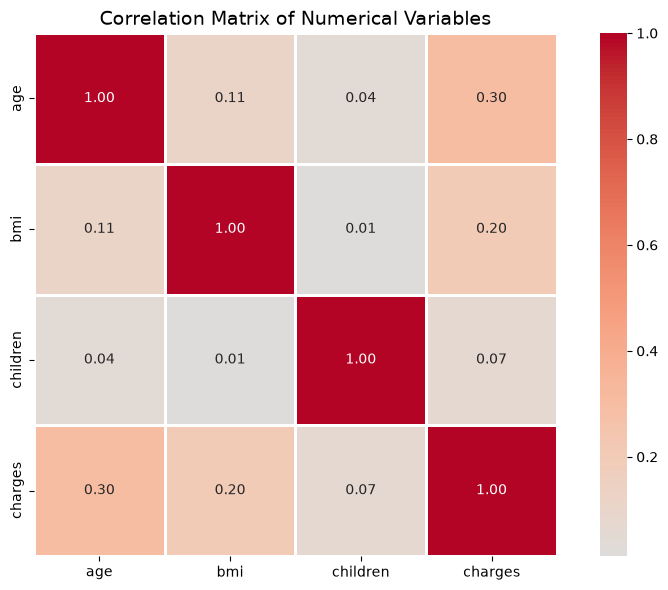

In [54]:
#correction

plt.figure(figsize=(9, 6))
numerical_cols = ['age', 'bmi', 'children', 'charges']
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()


Correlation analysis is used to examine the strength and direction of
linear relationships between numerical variables. This provides
additional information for feature selection before developing the
regression model.

In [55]:
#Data Preparation

In [56]:
# Convert categorical variables into dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [57]:
#Define Features and Target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X.head())
print("features:")
print("target:")
print("Target:")
print(y.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
features:
target:
Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [58]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   bool   
 5   smoker_yes        1337 non-null   bool   
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 58.8 KB


In [59]:
#Split the Datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Training set: 1069 samples
Testing set: 268 samples


In [60]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully")
print(f"Intercept: {model.intercept_:.2f}")
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Model trained successfully
Intercept: -11092.65
Coefficients:
age: 248.21
bmi: 318.70
children: 533.01
sex_male: -101.54
smoker_yes: 23077.76
region_northwest: -391.76
region_southeast: -838.92
region_southwest: -659.14


In [61]:
#Linear Regression Model Explanation
y_pred = model.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("First 10 predictions:")
print(results.head())

First 10 predictions:
           Actual     Predicted
900    8688.85885   8143.693884
1064   5708.86700   5737.115683
1256  11436.73815  14369.314876
298   38746.35510  31745.513636
237    4463.20510   8962.386657


In [62]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

comparison.head(10)


,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


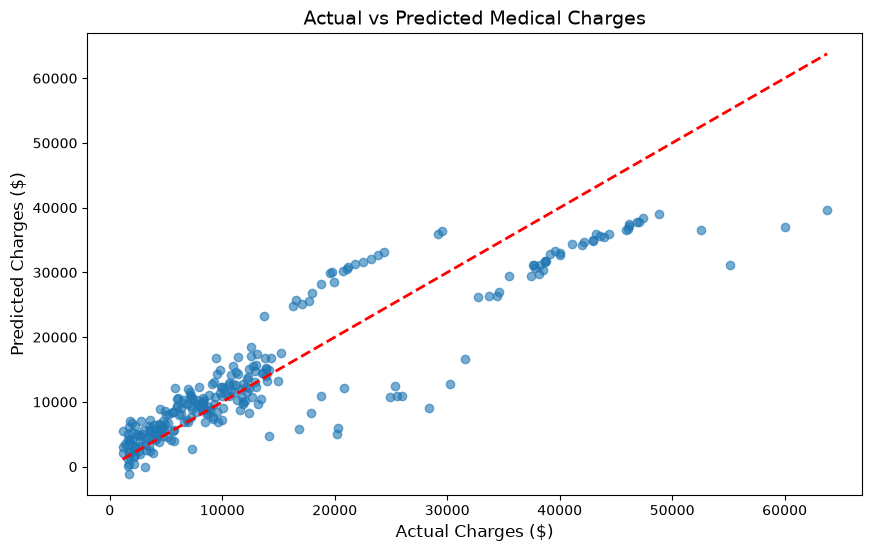

In [63]:

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Medical Charges', fontsize=14)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.show()

In [64]:
#Train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 248.21, 318.7 , 533.01,...,-391.76,-838.92,-659.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.109e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [65]:
#Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [66]:
#Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 4177.045561036319
Mean Squared Error: 35478020.67523559
R² Score: 0.8069287081198012




The Linear Regression model achieved an R² score of approximately 0.80
on the testing dataset. This indicates that the model explains
approximately 80% of the variation in medical insurance charges.

The Mean Absolute Error (MAE) represents the average absolute difference
between the actual and predicted insurance charges. The Root Mean
Squared Error (RMSE) gives greater weight to larger prediction errors.

Although the model provides a reasonable level of predictive
performance, some variation in medical charges remains unexplained.

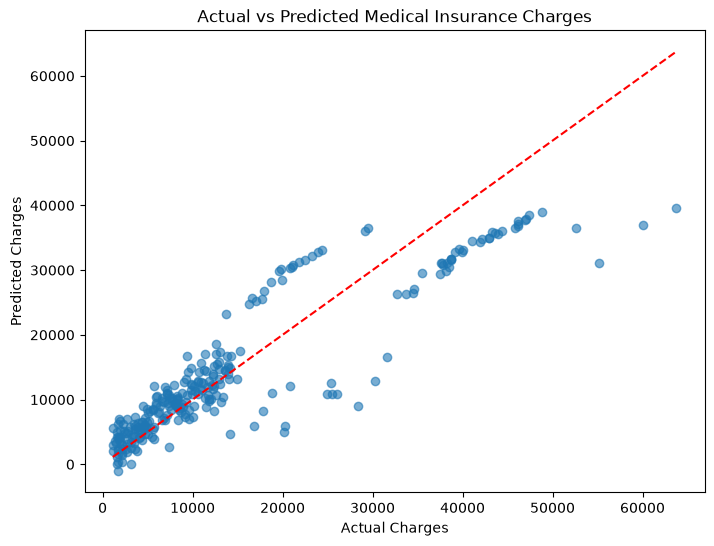

In [67]:
#plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Actual vs Predicted Medical Insurance Charges")

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.show()

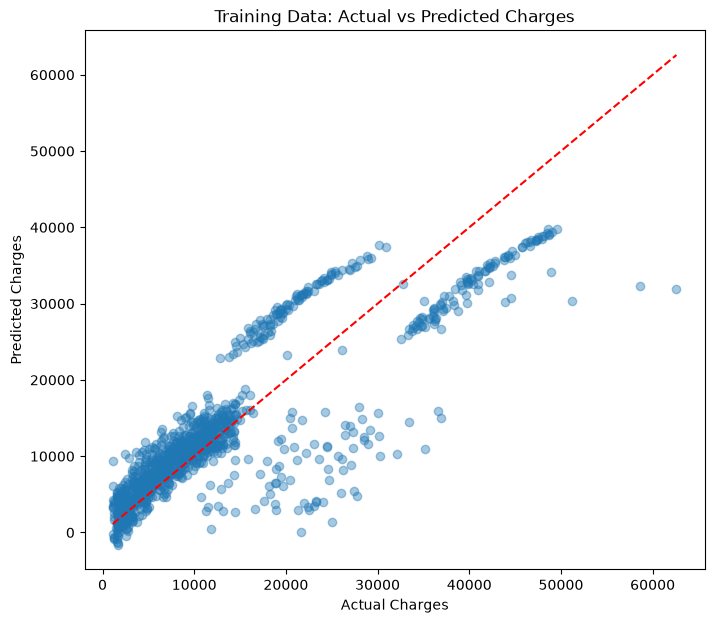

In [68]:
#Training vs testing predictions
plt.figure(figsize=(8, 7))

plt.scatter(y_train, y_train_pred, alpha=0.4)

plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    "r--"
)

plt.title("Training Data: Actual vs Predicted Charges")

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.show()

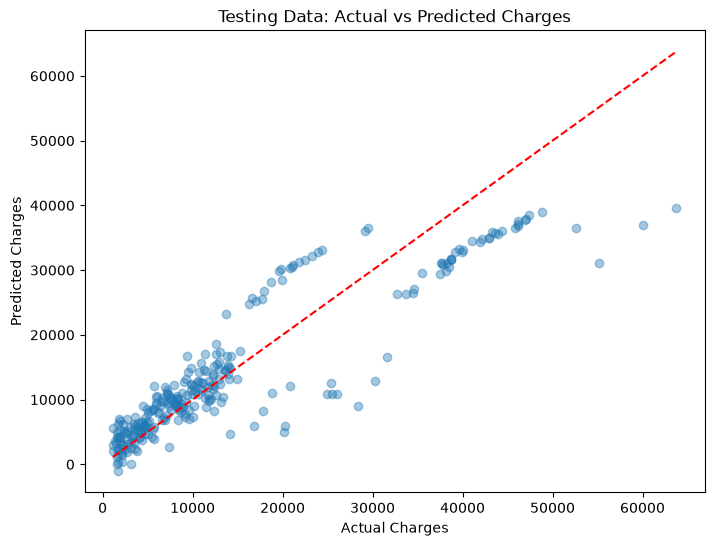

In [69]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Testing Data: Actual vs Predicted Charges")

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.show()

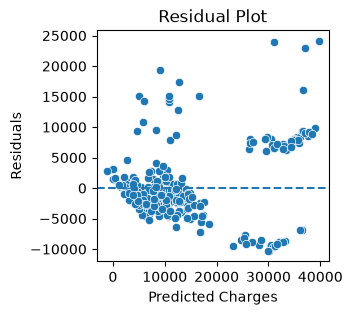

In [86]:
#Residual plot
residuals = y_test - y_test_pred
plt.figure(figsize=(3,3))
sns.scatterplot(x=y_test_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.show()

In [37]:
#Examine the model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,smoker_yes,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616


From the trained linear regression model, the largest positive coefficients were for:

smoker_yes has the biggest impact on charges
age indicates that older clients tend to have higher charges
bmi the higher the BMI the likely hood increase on charges

Conclusion

The analysis used Linear Regression to predict medical insurance
charges from demographic, health-related and lifestyle variables.

The exploratory analysis identified relationships between insurance
charges and variables such as age, BMI and smoking status. The dataset
contained no missing values, allowing the analysis to proceed without
missing-value imputation.

The Linear Regression model achieved an R² score of approximately 0.80
on the testing data, indicating that the model explains a substantial
proportion of the variation in medical insurance charges. However,
prediction errors remain, suggesting that additional factors may
influence insurance costs.

Overall, Linear Regression provides a useful baseline model for
predicting medical insurance charges and provides interpretable
coefficients that can be used to understand the contribution of the
predictor variables.

 References
 
Dataset Choi, M. (2017). Medical Cost Personal Dataset. Kaggle. https://www.kaggle.com/datasets/mirichoi0218/insurance




Linear Regression Analysis


Student: Maitele Funzani(10547359)

https://github.com/maittelle-cell/PDAN8411.git